# Classement des demandeurs d'emploi

Ce notebook présente le workflow complet de préparation, analyse, modélisation et évaluation d'un système de prédiction de la classe de retour à l'emploi.

Objectif métier : prédire la classe de retour à l'emploi à partir des informations du demandeur, de son parcours et de sa synthèse d'entretien.

Il s'agit d'un problème de classification supervisée multiclasse : le modèle apprend à associer ces caractéristiques à l'une des trois classes de retour à l'emploi.

Nous suivons une logique reproductible :
- contrôle qualité des données,
- feature engineering traçable,
- séparation train/test stratifiée,
- validation croisée et comparaison de modèles,
- sélection d'un pipeline de production.

### Description des données

| Colonne | Description |
|---|---|
| `usager_id` | Identifiant unique du demandeur d'emploi |
| `age` | Âge de l'usager en années |
| `niveau_diplome` | Plus haut niveau de diplôme obtenu (Sans diplôme, Bac, Bac+2, Bac+5) ; donnée potentiellement manquante |
| `anciennete_poste_ans` | Nombre d'années d'expérience dans le dernier emploi occupé |
| `code_rome_vise` | Code à 5 caractères du Répertoire Opérationnel des Métiers et des Emplois ciblé par l'usager |
| `code_insee_commune` | Code officiel géographique INSEE de la commune de résidence |
| `est_allocataire` | Statut d'indemnisation : 1 (oui), 0 (non) |
| `nationalite_hors_ue` | Variable sensible : 1 (nationalité hors Union européenne), 0 (nationalité UE) |
| `synthese_entretien` | Notes textuelles du conseiller lors de l'entretien |
| `classe_retour_emploi` | 0 = retour rapide (< 6 mois), 1 = retour moyen (6 à 12 mois), 2 = risque de retour de longue durée (> 12 mois) |

<h4 style="color:green">Jdb : Premier jour : Chargement des données et observation

## 1. Paramétrage, imports et chargement des données

Cette section rassemble les imports du projet et charge le jeu de données. Elle présente aussi les modules et paramètres partagés définis dans [src/config.py](../src/config.py) et [src/data.py](../src/data.py).

In [185]:
import importlib
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

In [186]:
sys.path.insert(0, str(Path.cwd().resolve().parent))

from src import config as C, data as D, models as M

importlib.reload(C)
importlib.reload(D)
importlib.reload(M)

plt.style.use("seaborn-v0_8-whitegrid")
SEED = C.SEED

print(f"Projet : {Path.cwd().resolve()}")

Projet : C:\CCS\Formations\IA\Exam\ProjetTriDemandeurEmploi\notebooks


In [187]:
import mlflow

MLFLOW_TRACKING_URI = C.MLFLOW_TRACKING_URI
MLFLOW_EXPERIMENT_NAME = C.MLFLOW_EXPERIMENT_INVESTIGATION

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

print(f"MLflow tracking URI : {mlflow.get_tracking_uri()}")
print(f"MLflow experiment : {MLFLOW_EXPERIMENT_NAME}")

MLflow tracking URI : sqlite:///C:/CCS/Formations/IA/Exam/ProjetTriDemandeurEmploi/mlflow.db
MLflow experiment : investigation


In [188]:
df = D.load_data().copy()

print(f"Nombre d'observations : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")
print("\nAperçu du dataset :")
display(df.head())

required_cols = {
    "usager_id",
    "age",
    "niveau_diplome",
    "anciennete_poste_ans",
    "code_rome_vise",
    "code_insee_commune",
    "est_allocataire",
    "nationalite_hors_ue",
    "synthese_entretien",
    "classe_retour_emploi",
}
missing_cols = sorted(required_cols - set(df.columns))

if missing_cols:
    raise ValueError(f"Colonnes manquantes : {missing_cols}")

print("\nSchéma OK : toutes les colonnes attendues sont présentes.")


Chargement du CSV : C:\CCS\Formations\IA\Exam\ProjetTriDemandeurEmploi\data\dataset_trajectoire_emploi_Sujet Examen CISIA.csv
Nombre d'observations : 2500
Nombre de colonnes : 10

Aperçu du dataset :


,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0
3,ID_0003,60.0,Bac,0.2,A1203,63359,1.0,0,Problème ponctuel de mobilité géographique. Zo...,1
4,ID_0004,25.0,Sans diplôme,1.2,N1301,21302,1.0,0,Projet de reconversion à affiner. Besoin d'une...,0



Schéma OK : toutes les colonnes attendues sont présentes.


Cet extrait du jeu de données permettent d'examiner sa structure générale ainsi que la nature des informations disponibles pour chaque usager.

On constate la présence de plusieurs types de variables : numériques, catégorielles, géographiques et textuelles. Cette première exploration met également en évidence l'existence de valeurs manquantes dans certaines colonnes, telles que est_allocataire. Ces données absentes devront être analysées et traitées lors de l'étape de prétraitement afin de garantir la qualité des analyses et des modèles qui seront développés par la suite.

## 2. Analyse exploratoire des données(EDA) et validation des données

Cette section produit les premiers diagnostics de qualité : types, valeurs manquantes, doublons et la distribution de la cible afin de caractériser le jeu de données chargé.

In [189]:
resume_types = pd.DataFrame({
    "type": df.dtypes,
    "valeurs_manquantes": df.isna().sum(),
    "pct_manquants": (df.isna().mean() * 100).round(2),
    "cardinalite": df.nunique(),
})

numeric_summary = (
    df[C.FEATURES_NUM]
    .agg(["min", "max", "mean", "std"])
    .T.rename(columns={"mean": "moyenne", "std": "ecart_type"})
    .round(2)
)
resume_types = resume_types.join(numeric_summary)

display(resume_types.sort_values(["pct_manquants", "cardinalite"], ascending=[False, True]))

,type,valeurs_manquantes,pct_manquants,cardinalite,min,max,moyenne,ecart_type
age,float64,122,4.88,46,18.0,63.0,40.57,13.23
niveau_diplome,str,84,3.36,4,NaN,NaN,NaN,NaN
synthese_entretien,str,81,3.24,9,NaN,NaN,NaN,NaN
est_allocataire,float64,44,1.76,2,NaN,NaN,NaN,NaN
nationalite_hors_ue,int64,0,0.00,2,NaN,NaN,NaN,NaN
classe_retour_emploi,int64,0,0.00,3,NaN,NaN,NaN,NaN
code_rome_vise,str,0,0.00,50,NaN,NaN,NaN,NaN
anciennete_poste_ans,float64,0,0.00,154,0.0,22.6,2.97,2.98
code_insee_commune,str,0,0.00,2407,NaN,NaN,NaN,NaN
usager_id,str,0,0.00,2500,NaN,NaN,NaN,NaN


### Nature des variables
Le jeu de données est composé de plusieurs types de variables:

**Variables numériques** :
- `age`
- `anciennete_poste_ans`


**Variables catégorielles :**
- `niveau_diplome`
- `est_allocataire` (variable binaire : 0 = non, 1 = oui)
- `nationalite_hors_ue` (variable binaire : 0 = nationalité de l'Union Européenne, 1 = hors Union Européenne)
- `code_rome_vise`
- `code_insee_commune`


**Variable textuelle :**
- `synthese_entretien`
 
### Analyse descriptive des variables
L'analyse descriptive des variables numériques met en évidence des profils relativement variés au sein de la population étudiée.

- La variable `age` varie de 18 à 63 ans, avec une moyenne de 40,6 ans, indiquant une population majoritairement composée d'adultes en milieu de carrière.
- L'`anciennete_poste_ans` s'étend de 0 à 22,6 ans, pour une moyenne d'environ 3 ans, ce qui suggère une proportion importante de personnes récemment positionnées sur leur poste.
- Les variables `est_allocataire` et nationalite_hors_ue sont des variables binaires codées en 0/1, représentant respectivement deux modalités possibles.
- La variable `cible` classe_retour_emploi comporte trois classes distinctes (0, 1 et 2), ce qui confirme qu'il s'agit d'un problème de classification multiclasse.

Concernant les variables catégorielles :

- `niveau_diplome` présente seulement quatre modalités, ce qui facilite son exploitation après encodage. La présence de quelques valeurs manquantes justifie néanmoins la mise en place d'une stratégie d'imputation afin de garantir la robustesse du modèle.
- `code_rome_vise` comporte 50 modalités distinctes dans le jeu de données étudié, reflétant la diversité des métiers recherchés. Cependant, le référentiel ROME comprend près de 2 000 codes différents. Afin de limiter la cardinalité tout en conservant une information métier pertinente, les codes seront regroupés à partir de leurs trois premiers caractères pour représenter des familles de métiers.
- `code_insee_commune` compte 2 407 valeurs distinctes, révélant une très forte cardinalité qui pourra nécessiter un regroupement ou un traitement spécifique afin d'éviter une explosion du nombre de variables après encodage.
- `synthese_entretien` ne contient que 10 formulations distinctes, ce qui laisse envisager un traitement simplifié de cette variable textuelle. Cependant, les futures synthes devrait etre des textes libres, une vectorisation sara donc plus pertinente.

Cette première analyse permet d'identifier les caractéristiques des données et d'anticiper les traitements de prétraitement à mettre en œuvre, notamment la gestion des variables à forte cardinalité, l'encodage des variables catégorielles et le traitement des éventuelles valeurs manquantes.

In [190]:
print(f"\nDoublons sur usager_id : {df['usager_id'].duplicated().sum()}")
print(f"Lignes dupliquées : {df.duplicated().sum()}")

class_counts = df[C.CIBLE].value_counts().rename_axis(C.CIBLE).reset_index(name="effectif")
class_counts["pct"] = (class_counts["effectif"] / len(df) * 100).round(2)
display(class_counts)


Doublons sur usager_id : 0
Lignes dupliquées : 0


,classe_retour_emploi,effectif,pct
0,1,1112,44.48
1,0,936,37.44
2,2,452,18.08


Aucune doublon n'a été detecté dans le fichier source

### Caracterisation de la cible :
La variable cible classe_retour_emploi présente trois modalités. 
- La classe 1 (retour à l'emploi entre 6 et 12 mois) est la plus représentée avec 44,48 % des observations, suivie de la classe 0 (retour rapide) avec 37,44 %. 
- La classe 2 (risque de retour à l'emploi de longue durée) est moins fréquente avec 18,08 % des observations. 
- La distribution reste relativement équilibrée, même si la classe 2 est sous-représentée. Cette situation justifie l'utilisation de métriques telles que la Balanced Accuracy et le F1-score afin d'évaluer correctement les performances des modèles sur l'ensemble des classes. Cette situation ne necessite pas de besoin de sous échantillonage ou de génération d'exemple synthetique (SMOTE).

<h4 style="color:green">Jdb : deuxième jour : Vérifier la qualité des données,  incoherence entre les colonnes

## 3. Contrôles qualité automatisés

Cette section produit les premiers diagnostics de qualité :  distribution, cohérences métier. L'objectif est de documenter les anomalies avant le prétraitement.

- 1. Analyse de l'age

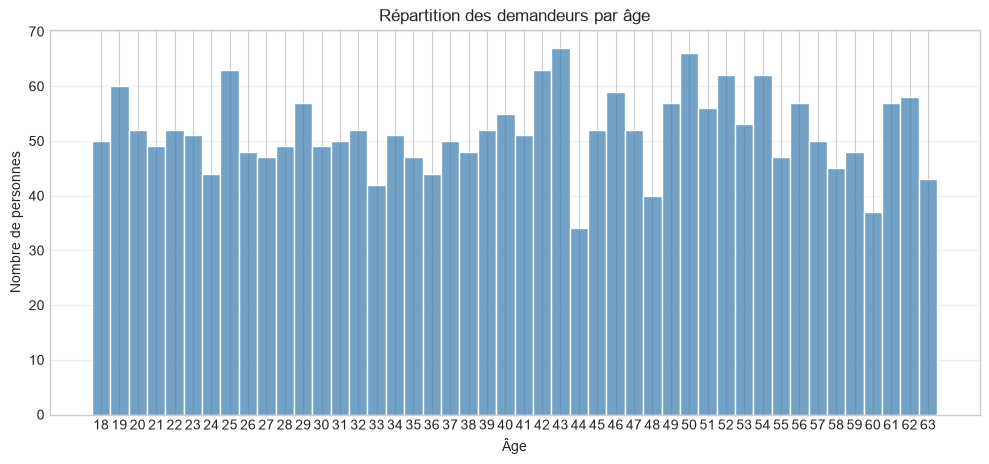

In [191]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="age",
    bins=range(17, 66),
    discrete=True,
    kde=False,
    color="steelblue",
    edgecolor="white",
)

plt.title("Répartition des demandeurs par âge")
plt.xlabel("Âge")
plt.ylabel("Nombre de personnes")
plt.xticks(range(18, 64))
plt.grid(axis="y", alpha=0.3)
plt.show()

Ce diagramme montre une repartition equitable des demanderurs d'emploi selon l'age. Ce qui n'est pas represntatif de la realité, mais qui va simplifier l'entrainement du model

- 2. analyse de l'ancienneté  dans le poste

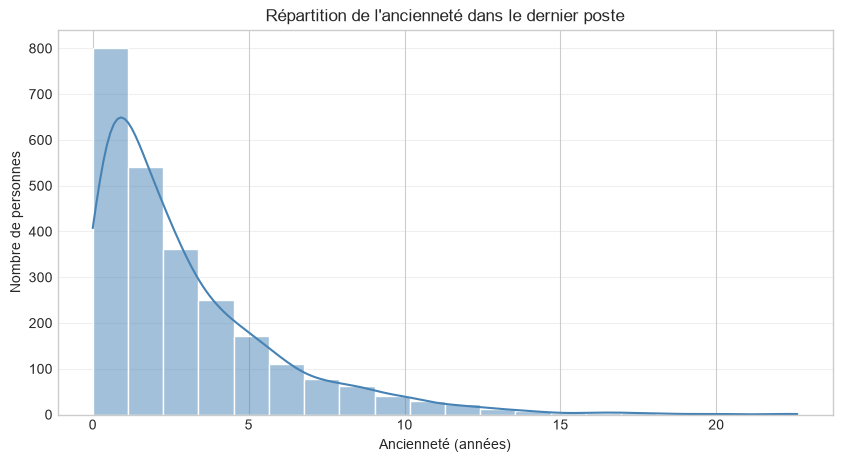

In [192]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="anciennete_poste_ans",
    bins=20,
    kde=True,
    color="steelblue",
    edgecolor="white",
)

plt.title("Répartition de l'ancienneté dans le dernier poste")
plt.xlabel("Ancienneté (années)")
plt.ylabel("Nombre de personnes")
plt.grid(axis="y", alpha=0.3)
plt.show()

Ce diagramme montre que l'ancienneté du poste a une moyenne d’environ 3 ans et une médiane de 2 ans. La majorité des usagers ont une ancienneté faible

- 3. analyse coherence age vs ancieneté poste

In [193]:
# Vérification de cohérence métier
age_debut_emploi = df["age"] - df["anciennete_poste_ans"]
incoherent_experience = age_debut_emploi < 16

coherence_summary = pd.DataFrame({
    "metric": [
        "observations_incoherentes",
        "pct_incoherentes",
        "age_min_theorique",
    ],
    "value": [
        int(incoherent_experience.sum()),
        round(incoherent_experience.mean() * 100, 2),
        round(age_debut_emploi.min(), 2),
    ],
})

display(coherence_summary)

,metric,value
0,observations_incoherentes,100.0
1,pct_incoherentes,4.0
2,age_min_theorique,1.8


Dans plusieurs cas, le calcul de l'âge théorique d'entrée dans la vie active (âge - ancienneté) aboutit à des valeurs inférieures à 16 ans, voire à quelques années seulement, ce qui révèle des incohérences probables dans les données.

In [194]:
#analyse diplome
col = "niveau_diplome"
serie = df[col].astype("object").fillna("Manquant")

tableau = (
    serie.value_counts(dropna=False)
    .reset_index()
)

tableau.columns = ["Modalité", "Effectif"]

tableau["Pourcentage (%)"] = (
    tableau["Effectif"] / len(serie) * 100
).round(2)

tableau["Pourcentage cumulé (%)"] = (
    tableau["Pourcentage (%)"]
    .cumsum()
).round(2)

display(tableau.head(10))

,Modalité,Effectif,Pourcentage (%),Pourcentage cumulé (%)
0,Bac,966,38.64,38.64
1,Bac+2,501,20.04,58.68
2,Sans diplôme,478,19.12,77.80
3,Bac+5,471,18.84,96.64
4,Manquant,84,3.36,100.00


In [195]:
# Vérification diplôme / âge
age_bins = pd.cut(df["age"], bins=[18, 25, 35, 45, 55, 65], include_lowest=True)
print("\nCrosstab : âge vs niveau de diplôme")
display(pd.crosstab(df["niveau_diplome"].fillna("Inconnu"), age_bins))

# Cas atypiques : diplome Bac+5 avec age jeune
cas_atypiques = df[(df["age"] < 20) & (df["niveau_diplome"] == "Bac+5")]
print(f"\nCas atypiques identifiés : {len(cas_atypiques)}")
if not cas_atypiques.empty:
    display(cas_atypiques[["usager_id", "age", "niveau_diplome", "code_rome_vise"]].head())


Crosstab : âge vs niveau de diplôme


age,"(17.999, 25.0]","(25.0, 35.0]","(35.0, 45.0]","(45.0, 55.0]","(55.0, 65.0]"
niveau_diplome,,,,,
Bac,189,186,185,219,145
Bac+2,66,96,118,116,75
Bac+5,80,89,90,111,74
Inconnu,14,16,22,11,19
Sans diplôme,72,105,101,97,82



Cas atypiques identifiés : 21


,usager_id,age,niveau_diplome,code_rome_vise
207,ID_0207,18.0,Bac+5,N1101
358,ID_0358,19.0,Bac+5,J1301
380,ID_0380,18.0,Bac+5,N1303
495,ID_0495,18.0,Bac+5,C1102
506,ID_0506,19.0,Bac+5,M1203


La variable `niveau_diplome` comporte quatre modalités principales. Le niveau *Bac* est le plus représenté, avec environ 39 % des observations. Cette variable présente également 3,36 % de valeurs manquantes. Compte tenu de ce faible taux d'absence, les données manquantes seront imputées par la modalité la plus fréquente afin de préserver le volume de données disponible. Comme indiqué précédemment, la variable sera également enrichie avec d'autres niveaux de diplôme susceptibles d'être observés dans de futures données (par exemple Bac+3, Bac+8), afin de garantir la robustesse et la capacité de généralisation du pipeline de prétraitement.

Une vérification de cohérence a été réalisée entre l'âge et le niveau de diplôme. Certaines observations présentent des situations peu plausibles, notamment des usagers âgés de 18 ou 19 ans déclarant un diplôme de niveau Bac+5 associé à plusieurs années d'expérience professionnelle.

<h4 style="color:green">Jdb : troisieme jour : analyse variables catégorielles

- 4. : Analyse des variables catégorielles

In [196]:
# Tableau récapitulatif des variables
resume_global = []

for col in C.FEATURES_CAT:

    serie = df[col].astype("object").fillna("Manquant")

    resume_global.append({
        "Variable": col,
        "Nb observations": len(serie),
        "Nb modalités": serie.nunique(),
        "Nb manquants": (serie == "Manquant").sum(),
        "% manquants": round((serie == "Manquant").mean() * 100, 2)
    })

display(
    pd.DataFrame(resume_global)
    .sort_values("Nb modalités", ascending=False)
)

# Détail des modalités
for col in C.FEATURES_CAT:

    print("\n" + "=" * 70)
    print(f"VARIABLE : {col}")
    print("=" * 70)

    serie = df[col].astype("object").fillna("Manquant")

    tableau = (
        serie.value_counts(dropna=False)
        .reset_index()
    )

    tableau.columns = ["Modalité", "Effectif"]

    tableau["Pourcentage (%)"] = (
        tableau["Effectif"] / len(serie) * 100
    ).round(2)

    tableau["Pourcentage cumulé (%)"] = (
        tableau["Pourcentage (%)"]
        .cumsum()
    ).round(2)

    display(tableau.head(10))

    print(
        f"Modalités uniques : {serie.nunique()} | "
        f"Taux de valeurs manquantes : "
        f"{round((serie == 'Manquant').mean()*100,2)} %"
    )

,Variable,Nb observations,Nb modalités,Nb manquants,% manquants
1,code_insee_commune,2500,2407,0,0.00
0,code_rome_vise,2500,50,0,0.00
2,est_allocataire,2500,3,44,1.76
3,nationalite_hors_ue,2500,2,0,0.00



VARIABLE : code_rome_vise


,Modalité,Effectif,Pourcentage (%),Pourcentage cumulé (%)
0,H1206,71,2.84,2.84
1,G1801,64,2.56,5.40
2,G1601,63,2.52,7.92
3,D1210,63,2.52,10.44
4,K1403,62,2.48,12.92
5,I1304,62,2.48,15.40
6,M1602,61,2.44,17.84
7,H2502,60,2.40,20.24
8,A1203,59,2.36,22.60
9,K1304,58,2.32,24.92


Modalités uniques : 50 | Taux de valeurs manquantes : 0.0 %

VARIABLE : code_insee_commune


,Modalité,Effectif,Pourcentage (%),Pourcentage cumulé (%)
0,46283,3,0.12,0.12
1,34045,3,0.12,0.24
2,76493,2,0.08,0.32
3,55008,2,0.08,0.40
4,58224,2,0.08,0.48
5,28407,2,0.08,0.56
6,11120,2,0.08,0.64
7,09261,2,0.08,0.72
8,27288,2,0.08,0.80
9,11028,2,0.08,0.88


Modalités uniques : 2407 | Taux de valeurs manquantes : 0.0 %

VARIABLE : est_allocataire


,Modalité,Effectif,Pourcentage (%),Pourcentage cumulé (%)
0,1.0,1463,58.52,58.52
1,0.0,993,39.72,98.24
2,Manquant,44,1.76,100.00


Modalités uniques : 3 | Taux de valeurs manquantes : 1.76 %

VARIABLE : nationalite_hors_ue


,Modalité,Effectif,Pourcentage (%),Pourcentage cumulé (%)
0,0,2205,88.2,88.2
1,1,295,11.8,100.0


Modalités uniques : 2 | Taux de valeurs manquantes : 0.0 %


L'analyse des variables catégorielles met en évidence plusieurs caractéristiques importantes du jeu de données et permet d'orienter les choix de prétraitement.

La variable `est_allocataire` indique que 58,52 % des usagers sont allocataires, contre 39,72 % de non-allocataires. Le taux de valeurs manquantes est de 1,76 %. Ces valeurs absentes seront remplacées par la modalité majoritaire afin de conserver l'information et d'éviter une perte d'observations.

La variable `nationalite_hors_ue` présente un fort déséquilibre de répartition : 88,2 % des usagers appartiennent à la catégorie 0 contre 11,8 % à la catégorie 1. Par ailleurs, cette variable est susceptible d'être considérée comme sensible au regard des enjeux d'équité et de non-discrimination. . Son intégration au modèle devra donc faire l'objet d'une analyse approfondie dans la section dédiée aux aspects éthiques et réglementaires, afin d'évaluer les risques potentiels de biais ou de discrimination algorithmique et de vérifier sa conformité aux principes du RGPD, de la CNIL et de l'AI Act.

La variable `code_rome_vise` contient 50 modalités différentes correspondant aux métiers recherchés par les usagers. Les effectifs sont relativement répartis entre les différentes catégories, sans qu'un code particulier ne soit fortement dominant.
Afin de réduire la cardinalité tout en conservant une information métier pertinente, les codes ROME seront regroupés à partir de leurs trois premiers caractères. Cette transformation permet de représenter des familles de métiers plus générales, de limiter le nombre de modalités à encoder et de favoriser la capacité de généralisation des modèles.

La variable `code_insee_commune` présente une très forte cardinalité avec 2 407 modalités différentes pour 2 500 observations. L'utilisation directe de cette variable risquerait d'introduire beaucoup de bruit et de complexifier inutilement les modèles. Un travail de feature engineering sera donc réalisé afin d'extraire une information géographique plus pertinente, comme le département de résidence, qui devrait conserver l'essentiel de l'information tout en réduisant fortement le nombre de modalités.

<h4 style="color:green;">Jdb : jour 4 : Analyse coherence code_rome_vise vs niveau d'etude. En partant d'un exemple le code ROME K2106 correspond  au poste Professeur / Professeure des écoles, et necessite une reussite aux examens bac+5 depuis 2011

- 5. Coherence code_rome_vise

In [197]:
# Filtrer les personnes visant K2106
df_k2106 = df[df["code_rome_vise"] == "K2106"]
print("Nombre de candidats :", len(df_k2106))

# Effectifs par niveau de diplôme
print(df_k2106["niveau_diplome"].value_counts(dropna=False))

Nombre de candidats : 47
niveau_diplome
Sans diplôme    15
Bac             14
Bac+2           13
Bac+5            5
Name: count, dtype: int64


In [198]:
# Cas potentiellement incohérents
anomalies_k2106 = df[
    (df["code_rome_vise"] == "K2106") &
    
    (df["niveau_diplome"] == "Sans diplôme")
]

print(f"Nombre de cas trouvés : {len(anomalies_k2106)}")

display(
    anomalies_k2106[
        ["usager_id", "age", "niveau_diplome", "code_rome_vise"]
    ]
)

Nombre de cas trouvés : 15


,usager_id,age,niveau_diplome,code_rome_vise
192,ID_0192,41.0,Sans diplôme,K2106
262,ID_0262,22.0,Sans diplôme,K2106
453,ID_0453,63.0,Sans diplôme,K2106
785,ID_0785,59.0,Sans diplôme,K2106
1089,ID_1089,37.0,Sans diplôme,K2106
1270,ID_1270,47.0,Sans diplôme,K2106
1473,ID_1473,47.0,Sans diplôme,K2106
1503,ID_1503,18.0,Sans diplôme,K2106
1634,ID_1634,31.0,Sans diplôme,K2106
1857,ID_1857,20.0,Sans diplôme,K2106


L’analyse met en évidence plusieurs incohérences entre le niveau de diplôme de certains demandeurs d’emploi et le métier associé au `code_rome_vise`. Ces écarts peuvent résulter d’erreurs de saisie, aussi bien sur la variable relative au diplôme que sur le code ROME renseigné. Dans le cadre de cette étude, l’hypothèse retenue est que l’incohérence provient principalement du métier visé. En effet, un demandeur d’emploi peut finalement retrouver un emploi dans un domaine différent de celui initialement envisagé, ce qui limite la fiabilité de cette information comme indicateur strict de son parcours professionnel. Aucune correction ni imputation ne sera réalisée sur les données afin de préserver l'intégrité du jeu de données et d'éviter l'introduction de biais liés à des hypothèses non vérifiables.

<h4 style="color:green">Jdb : jour 5 : analyse de l'entretien

- 6. analyse synthese_entretien

In [199]:
syntheses = pd.DataFrame({
    "Effectif": df["synthese_entretien"].value_counts(dropna=False),
    "Pourcentage (%)": (
        df["synthese_entretien"]
        .value_counts(dropna=False, normalize=True) * 100
    ).round(2)
})

display(syntheses)

,Effectif,Pourcentage (%)
synthese_entretien,,
Compétences à réactualiser sur les outils numériques. Motivation correcte.,338,13.52
Problème ponctuel de mobilité géographique. Zone mal desservie.,334,13.36
"Profil autonome, recherche active, aucun frein périphérique identifié.",300,12.00
Projet de reconversion à affiner. Besoin d'une formation complémentaire.,275,11.00
"Excellente présentation, compétences techniques à jour. Reprise rapide visée.",272,10.88
"Candidat très dynamique, mobilité nationale validée. Projet clair.",259,10.36
Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.,227,9.08
"Perte de confiance importante. Risque d'exclusion, barrière de la langue.",212,8.48
Freins périphériques majeurs. Situation d'illettrisme numérique constatée.,202,8.08


L'analyse de la variable `synthese_entretien` révèle neuf formulations distinctes, ainsi que quelques valeurs manquantes correspondant à des entretiens non renseignés. Même si cette faible diversité limite la richesse du vocabulaire, cette variable sera conservée afin de respecter la consigne d'utiliser l'intégralité des variables disponibles, y compris le texte.

Les synthèses d'entretien seront donc transformées en caractéristiques numériques à l'aide d'une vectorisation TF-IDF. Cette méthode attribue un poids aux termes en fonction de leur fréquence dans une synthèse et de leur rareté dans l'ensemble des observations. Les valeurs manquantes seront traitées comme des textes vides avant la vectorisation, puis les caractéristiques obtenues seront intégrées aux variables tabulaires dans le pipeline de prétraitement.

Le nombre réduit de formulations peut toutefois limiter l'apport de cette représentation. Son utilité devra être vérifiée lors de l'évaluation, sur les données de test, en comparant les performances avec et sans cette variable. Les résultats seront également interprétés avec prudence : les formulations peuvent refléter les pratiques de saisie des conseillers autant que la situation des usagers, et ainsi introduire un biais dans les prédictions.

Certaines informations du texte synthese entretien peuvent être sources d'un risque ethic elevée, ou d'un biais indirects: "barriere de la langue", "situation d'illétrisme"

<h4 style="color:green">Jdb : jour 6 : Identification des variables les plus influentes pour la prédiction de la cible

In [200]:
# Tableau croisé des âges et des classes de retour à l'emploi
# Création des tranches d'âge de 5 ans
df["tranche_age"] = pd.cut(
    df["age"],
    bins=range(15, 70, 5),  # 15-20, 20-25, ..., 60-65
    right=False
)

tableau = pd.crosstab(
    df["tranche_age"],
    df["classe_retour_emploi"],
    normalize="index"
) * 100

tableau = tableau.round(2)

display(tableau)

classe_retour_emploi,0,1,2
tranche_age,,,
"[15, 20)",38.18,47.27,14.55
"[20, 25)",35.89,49.19,14.92
"[25, 30)",48.48,38.26,13.26
"[30, 35)",52.05,38.93,9.02
"[35, 40)",53.11,39.00,7.88
"[40, 45)",48.89,42.96,8.15
"[45, 50)",50.38,40.38,9.23
"[50, 55)",18.39,51.84,29.77
"[55, 60)",12.96,49.39,37.65


L’âge semble être une variable prédictive importante, notamment après 50 ans, mais il présente également un risque de discrimination. Il peut être conservé sous réserve d’une analyse d’équité et d’une comparaison des performances avec et sans cette variable. 

In [201]:
# Tableau croisé de l'ancienneté dans le poste et des classes de retour à l'emploi
tableau = pd.crosstab(
        df["anciennete_poste_ans"],
        df["classe_retour_emploi"],
        normalize="index"
    ) * 100
tableau = tableau.round(2)
display(tableau)

classe_retour_emploi,0,1,2
anciennete_poste_ans,,,
0.0,30.30,51.52,18.18
0.1,37.88,45.45,16.67
0.2,42.71,39.58,17.71
0.3,41.46,40.24,18.29
0.4,29.87,49.35,20.78
...,...,...,...
18.3,100.00,0.00,0.00
19.6,0.00,100.00,0.00
20.2,0.00,100.00,0.00


L’ancienneté dans le poste présente 154 valeurs distinctes. L’analyse valeur par valeur ne permet pas d’identifier clairement une tendance et produit des pourcentages extrêmes pour certaines anciennetés élevées. Il est donc préférable de conserver cette variable sous forme numérique pour la modélisation et de la regrouper en tranches pour l’analyse descriptive. L’effet réel de l’ancienneté devra ensuite être vérifié grâce à l’importance des variables ou aux valeurs SHAP

classe_retour_emploi,0,1,2
niveau_diplome,,,
Bac,364,465,137
Bac+2,189,248,64
Bac+5,299,138,34
Inconnu,27,38,19
Sans diplôme,57,223,198


,Classe 0 (%),Classe 1 (%),Classe 2 (%)
niveau_diplome,,,
Bac,37.68,48.14,14.18
Bac+2,37.72,49.50,12.77
Bac+5,63.48,29.30,7.22
Inconnu,32.14,45.24,22.62
Sans diplôme,11.92,46.65,41.42


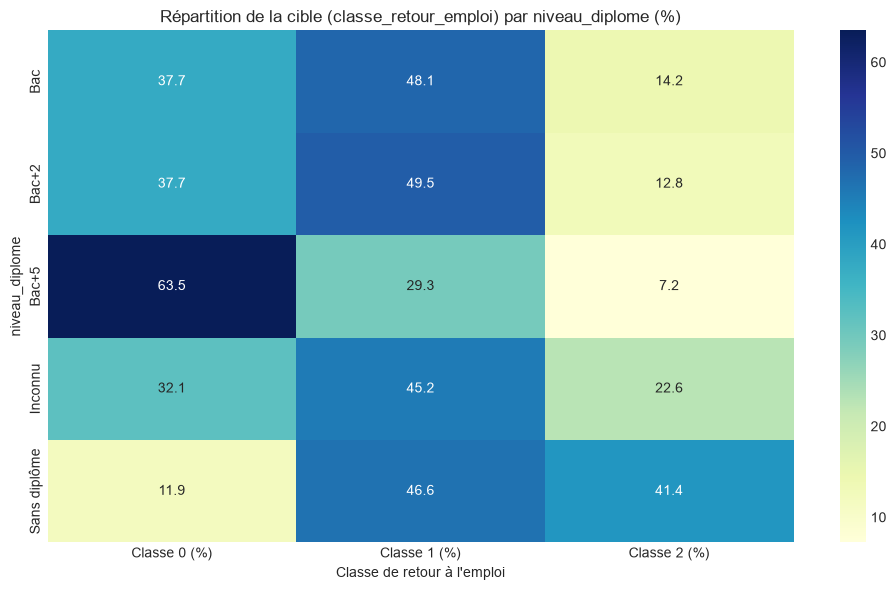

In [202]:
# Exemple : Répartition de la cible par niveau de diplôme
feature = "niveau_diplome"
cible = "classe_retour_emploi"

# Tableau effectifs
tab_effectif = pd.crosstab(
    df[feature].fillna("Inconnu"),
    df[cible]
)

display(tab_effectif)

# Tableau en pourcentage par ligne
tab_pct = pd.crosstab(
    df[feature].fillna("Inconnu"),
    df[cible],
    normalize="index"
).mul(100).round(2)

tab_pct.columns = [f"Classe {col} (%)" for col in tab_pct.columns]
display(tab_pct)

# Heatmap visuel
plt.figure(figsize=(10, 6))
sns.heatmap(
    tab_pct,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar=True
)
plt.title(f"Répartition de la cible ({cible}) par {feature} (%)")
plt.ylabel(feature)
plt.xlabel("Classe de retour à l'emploi")
plt.tight_layout()
plt.show()

Le niveau de diplôme semble influencer la prédiction du retour à l’emploi. Le Bac+5 est davantage associé à un retour rapide, tandis que l’absence de diplôme est plus fréquemment associée à un retour de longue durée. Cependant, il s’agit d’une corrélation descriptive qui doit être confirmée par l’analyse du modèle, par exemple avec l’importance des variables ou les valeurs SHAP.

In [203]:
# Tableau croisé de l'allocation et des classes de retour à l'emploi
tableau = pd.crosstab(
        df["est_allocataire"],
        df["classe_retour_emploi"],
        normalize="index"
    ) * 100
tableau = tableau.round(2)
display(tableau)

classe_retour_emploi,0,1,2
est_allocataire,,,
0.0,37.87,43.50,18.63
1.0,37.12,45.18,17.70


Le statut d’allocataire semble avoir une influence limitée sur le retour à l’emploi, car les distributions des trois classes sont presque identiques entre allocataires et non-allocataires. Cette variable peut être conservée dans un premier temps, puis son utilité réelle doit être vérifiée à partir des performances du modèle et des valeurs SHAP.

In [204]:
tableau = pd.crosstab(
        df["nationalite_hors_ue"],
        df["classe_retour_emploi"],
        normalize="index"
    ) * 100
tableau = tableau.round(2)
display(tableau)

classe_retour_emploi,0,1,2
nationalite_hors_ue,,,
0,40.59,43.99,15.42
1,13.90,48.14,37.97


La variable nationalite_hors_ue est fortement associée à la classe cible, notamment à la classe de retour de longue durée. Cependant, cette forte capacité de séparation constitue précisément un risque de discrimination. Je recommande donc de l’exclure du modèle opérationnel et de l’utiliser, si cela est juridiquement encadré, uniquement pour mesurer les écarts d’équité entre les groupes.

In [205]:
# Tableau croisé du code ROME visé et des classes de retour à l'emploi
tableau = pd.crosstab(
        df["code_rome_vise"],
        df["classe_retour_emploi"],
        normalize="index"
    ) * 100
tableau = tableau.round(2)
display(tableau)

classe_retour_emploi,0,1,2
code_rome_vise,,,
A1202,15.91,63.64,20.45
A1203,11.86,66.10,22.03
A1301,20.00,60.00,20.00
A1401,24.53,54.72,20.75
A1501,26.67,46.67,26.67
C1102,42.11,42.11,15.79
C1110,37.74,43.40,18.87
C1201,54.90,31.37,13.73
C1302,45.28,39.62,15.09


Le code ROME semble avoir une influence sur la classe de retour à l'emploi. Certains métiers sont fortement associés à un retour rapide, comme J1506 (77,08 % de classe 0) ou J1301 (70,83 % de classe 0), tandis que d'autres présentent une proportion plus élevée de classe 2, comme M1602 (39,34 %) ou M1607 (39,02 %). Ces différences suggèrent que le métier visé constitue une variable pertinente pour la prédiction du délai de retour à l'emploi. Le code ROME sera donc conservé comme variable explicative, tout en surveillant sa forte cardinalité et en envisageant un regroupement des modalités rares

In [206]:
tableau = pd.crosstab(
    df["code_rome_vise"].astype("string")
        .str.strip()
        .str[:3],   # conserve les 3 premiers caractères
    df["classe_retour_emploi"],
    normalize="index"
) * 100

tableau = tableau.round(2)
display(tableau)

classe_retour_emploi,0,1,2
code_rome_vise,,,
A12,13.59,65.05,21.36
A13,20.00,60.00,20.00
A14,24.53,54.72,20.75
A15,26.67,46.67,26.67
C11,39.56,42.86,17.58
C12,54.90,31.37,13.73
C13,45.28,39.62,15.09
C15,28.89,48.89,22.22
D12,41.27,42.86,15.87


Le regroupement à trois caractères conserve les principales différences observées:
J15 reste fortement associé à la classe 0 : 77,08 % ;
M16 reste fortement associé à la classe 2 : 39,22 % ;
A12 reste principalement associé à la classe 1 : 65,05 % ;
M18 présente 55,02 % en classe 0 et seulement 8,13 % en classe 2.

Cette granularité comporte 39 modalités. Elle réduit donc la cardinalité tout en conservant des différences métier importantes.

In [207]:
tableau = pd.crosstab(
        df["code_rome_vise"].astype("string")
            .str.strip()
            .str[0],
        df["classe_retour_emploi"],
        normalize="index"
    ) * 100
tableau = tableau.round(2)
display(tableau)

classe_retour_emploi,0,1,2
code_rome_vise,,,
A,19.52,58.57,21.91
C,42.08,40.83,17.08
D,37.90,43.95,18.15
F,15.79,57.89,26.32
G,27.63,52.92,19.46
H,36.11,52.22,11.67
I,56.45,25.81,17.74
J,73.96,20.83,5.21
K,38.78,41.58,19.64


Le regroupement par grande famille ne comporte plus que 12 modalités. Il reste informatif : la famille J compte 73,96 % de classe 0, tandis que F présente 26,32 % de classe 2. Toutefois, certaines tendances sont fortement lissées. Par exemple, la famille M ne présente plus que 19,56 % de classe 2, alors que le sous-groupe M16 atteint 39,22 %.

Je recommande d’utiliser le code ROME tronqué à trois caractères comme variable principale.

Il offre le meilleur compromis entre :

conservation de l’information métier ;
réduction de la cardinalité ;
limitation du risque de surapprentissage ;
meilleure représentation statistique des catégories.

In [208]:
# Classement des demandeurs d'emploi par code INSEE de la commune (2 premiers chiffres)
tableau = pd.crosstab(
        df["code_insee_commune"].astype(str)
            .str[:2],
        df["classe_retour_emploi"],
        normalize="index"
    ) * 100
tableau = tableau.round(2)
display(tableau)

classe_retour_emploi,0,1,2
code_insee_commune,,,
01,35.71,39.29,25.00
02,18.64,42.37,38.98
03,41.18,41.18,17.65
04,25.00,50.00,25.00
05,41.67,25.00,33.33
...,...,...,...
92,0.00,0.00,100.00
93,0.00,33.33,66.67
94,0.00,66.67,33.33


La répartition des classes varie selon le département extrait du code INSEE, ce qui suggère une association entre le territoire de résidence et le retour à l’emploi. Toutefois, la variable comporte 96 modalités et certaines distributions extrêmes peuvent être liées à de faibles effectifs. De plus, le territoire peut constituer un indicateur indirect de caractéristiques socio-économiques. Il est donc recommandé de regrouper les départements rares, d’envisager un regroupement par région et de comparer les performances avec un scénario excluant cette variable.

In [209]:
tableau = pd.crosstab(
        df["synthese_entretien"],
        df["classe_retour_emploi"],
        normalize="index"
    ) * 100
tableau = tableau.round(2)
display(tableau)

classe_retour_emploi,0,1,2
synthese_entretien,,,
"Candidat très dynamique, mobilité nationale validée. Projet clair.",67.95,23.55,8.49
Compétences à réactualiser sur les outils numériques. Motivation correcte.,14.50,78.40,7.10
Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.,25.11,26.87,48.02
"Excellente présentation, compétences techniques à jour. Reprise rapide visée.",71.69,20.59,7.72
Freins périphériques majeurs. Situation d'illettrisme numérique constatée.,25.74,29.70,44.55
"Perte de confiance importante. Risque d'exclusion, barrière de la langue.",29.72,24.06,46.23
Problème ponctuel de mobilité géographique. Zone mal desservie.,16.77,74.55,8.68
"Profil autonome, recherche active, aucun frein périphérique identifié.",69.67,22.00,8.33
Projet de reconversion à affiner. Besoin d'une formation complémentaire.,17.09,75.27,7.64


La synthèse d’entretien apparaît comme l’une des variables les plus informatives du projet, car certaines formulations sont fortement associées aux différentes classes de retour à l’emploi. Son utilisation améliore potentiellement la prédiction, mais nécessite un contrôle éthique en raison des informations sensibles pouvant être présentes dans le texte

<h4 style="color:green">Jdb : jour 7 : Feature engineering

## 4. Feature engineering traçable avant split

Avant le split, nous appliquons uniquement des transformations déterministes sur les lignes individuelles. Cela évite la fuite d'information entre train et test tout en améliorant la robustesse du jeu de données.


In [210]:
data = df.copy()

# Variables dérivées déterministes
# 1) département extrait depuis le code commune INSEE
# 2) famille métier définie par les 3 premiers caractères du code ROME
# 3) niveau diplôme ordinal
# 4) texte nettoyé pour le TF-IDF

data["departement"] = (
    data["code_insee_commune"]
    .astype("string")
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(5)
    .str[:2]
)

data["famille_metier"] = (
    data["code_rome_vise"]
    .astype("string")
    .str.strip()
    .str[:3]
)

data["niveau_diplome_ordinal"] = data["niveau_diplome"].map(C.ordre_niveau_diplome)

data["synthese_entretien"] = data["synthese_entretien"].fillna("").astype(str)

# Correction explicite des incohérences métier
mask = data["anciennete_poste_ans"] > (data["age"] - 16)
data.loc[mask, "anciennete_poste_ans"] = data.loc[mask, "age"] - 16

print(f"Nombre d'observations corrigées : {int(mask.sum())}")
print("Exemple de données transformées :")
display(data[["age", "anciennete_poste_ans", "niveau_diplome_ordinal", "departement", "famille_metier"]].head())

Nombre d'observations corrigées : 100
Exemple de données transformées :


,age,anciennete_poste_ans,niveau_diplome_ordinal,departement,famille_metier
0,56.0,2.6,NaN,18,D15
1,46.0,10.5,1.0,07,G13
2,NaN,1.4,2.0,01,M17
3,60.0,0.2,2.0,63,A12
4,25.0,1.2,1.0,21,N13


## 5. Définition explicite des scénarios de variables

Les scénarios sont construits à partir des listes de features centralisées dans le projet, ce qui évite toute divergence entre le notebook et la configuration logicielle.


In [211]:
scenario_definitions = {
    "complet": {
        "features": C.FEATURES_SCENARIO_1,
        "description": "Approche multimodale complète",
    },
    "scenario_2": {
        "features": C.FEATURES_SCENARIO_2,
        "description": "Sans âge, nationalité hors UE et statut allocataire",
    },
    "scenario_2B": {
        "features": C.FEATURES_SCENARIO_2B,
        "description": "Âge conservé, sans nationalité hors UE",
    },
    "scenario_2C": {
            "features": C.FEATURES_SCENARIO_2C,
            "description": "Âge conservé, sans nationalité hors UE et statut allocataire",
    },
    "texte_seul": {
        "features": C.FEATURES_SCENARIO_3,
        "description": "Diagnostic par le texte seul",
    },
    "tabulaire_seul": {
        "features": C.FEATURES_SCENARIO_4,
        "description": "Données contextuelles seules",
    },
}

for name, cfg in scenario_definitions.items():
    features = cfg["features"]
    missing = [col for col in features if col not in data.columns]
    if missing:
        raise ValueError(f"Scénario {name} contient des colonnes absentes : {missing}")
    print(f"{name}: {cfg['description']} -> {len(features)} features")

complet: Approche multimodale complète -> 8 features
scenario_2: Sans âge, nationalité hors UE et statut allocataire -> 5 features
scenario_2B: Âge conservé, sans nationalité hors UE -> 7 features
scenario_2C: Âge conservé, sans nationalité hors UE et statut allocataire -> 6 features
texte_seul: Diagnostic par le texte seul -> 1 features
tabulaire_seul: Données contextuelles seules -> 4 features


<h4 style="color:green">Jdb : jour 8 : separation train test validation

In [212]:
X = data[C.FEATURES_SCENARIO_1].copy()
y = data[C.CIBLE].copy()

indices_train_validation, indices_test = train_test_split(
    data.index,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)
indices_train, indices_validation = train_test_split(
    indices_train_validation,
    test_size=0.25,
    random_state=SEED,
    stratify=y.loc[indices_train_validation],
)

X_train = X.loc[indices_train].copy()
X_validation = X.loc[indices_validation].copy()
X_test = X.loc[indices_test].copy()
y_train = y.loc[indices_train].copy()
y_validation = y.loc[indices_validation].copy()
y_test = y.loc[indices_test].copy()

print(f"Train shape : {X_train.shape}")
print(f"Validation shape : {X_validation.shape}")
print(f"Test shape (réservé) : {X_test.shape}")
print(f"Distribution y_train :\n{y_train.value_counts(normalize=True).mul(100).round(2).to_string()}")

assert set(indices_train).isdisjoint(indices_validation)
assert set(indices_train).isdisjoint(indices_test)
assert set(indices_validation).isdisjoint(indices_test)
assert len(indices_train) + len(indices_validation) + len(indices_test) == len(data)
assert C.CIBLE not in X_train.columns
assert C.CIBLE not in X_validation.columns
assert C.CIBLE not in X_test.columns

Train shape : (1500, 8)
Validation shape : (500, 8)
Test shape (réservé) : (500, 8)
Distribution y_train :
classe_retour_emploi
1    44.47
0    37.47
2    18.07


## 6. Split train/test unique et réutilisable

Le split est défini une seule fois avec les index conservés. Tous les scénarios réutilisent ensuite ces mêmes index pour garantir une comparaison équitable entre configurations.


In [213]:
def build_scenario_split(scenario_features):
    X_s = data[scenario_features].copy()
    return (
        X_s.loc[indices_train].copy(),
        X_s.loc[indices_validation].copy(),
        X_s.loc[indices_test].copy(),
        y.loc[indices_train].copy(),
        y.loc[indices_validation].copy(),
        y.loc[indices_test].copy(),
    )

for scenario_name, cfg in scenario_definitions.items():
    X_train_s, X_validation_s, X_test_s, y_train_s, y_validation_s, y_test_s = (
        build_scenario_split(cfg["features"])
    )
    print(
        f"{scenario_name}: train={X_train_s.shape}, "
        f"validation={X_validation_s.shape}, test réservé={X_test_s.shape}"
    )
    assert list(y_train_s.index) == list(y_train.index)
    assert list(y_validation_s.index) == list(y_validation.index)
    assert list(y_test_s.index) == list(y_test.index)

complet: train=(1500, 8), validation=(500, 8), test réservé=(500, 8)
scenario_2: train=(1500, 5), validation=(500, 5), test réservé=(500, 5)
scenario_2B: train=(1500, 7), validation=(500, 7), test réservé=(500, 7)
scenario_2C: train=(1500, 6), validation=(500, 6), test réservé=(500, 6)
texte_seul: train=(1500, 1), validation=(500, 1), test réservé=(500, 1)
tabulaire_seul: train=(1500, 4), validation=(500, 4), test réservé=(500, 4)


In [214]:
def build_preprocessor(scenario_name: str):
    features = scenario_definitions[scenario_name]["features"]
    numeric_cols = [col for col in C.FEATURES_NUM if col in features]
    ordinal_cols = [col for col in C.FEATURES_CAT_ORDINAL if col in features]
    categorical_cols = [col for col in C.FEATURES_CAT if col in features]
    text_cols = [col for col in C.FEATURE_TEXT if col in features]

    transformers = []

    if numeric_cols:
        transformers.append(
            (
                "numeriques",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric_cols,
            )
        )

    if ordinal_cols:
        transformers.append(
            (
                "ordinal",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                ordinal_cols,
            )
        )

    if categorical_cols:
        transformers.append(
            (
                "categorielles",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
                ]),
                categorical_cols,
            )
        )

    if text_cols:
        transformers.append(
            (
                "texte",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="constant", fill_value="")),
                    ("flatten", FunctionTransformer(np.ravel, validate=False)),
                    ("tfidf", TfidfVectorizer()),
                ]),
                text_cols,
            )
        )

    return ColumnTransformer(transformers=transformers, remainder="drop")

for scenario_name in scenario_definitions:
    pp = build_preprocessor(scenario_name)
    X_train_s, X_validation_s, _, _, _, _ = build_scenario_split(
        scenario_definitions[scenario_name]["features"]
    )
    X_train_pp = pp.fit_transform(X_train_s)
    X_validation_pp = pp.transform(X_validation_s)
    print(
        f"{scenario_name}: train={X_train_pp.shape}, "
        f"validation={X_validation_pp.shape}"
    )

complet: train=(1500, 75), validation=(500, 75)
scenario_2: train=(1500, 70), validation=(500, 70)
scenario_2B: train=(1500, 73), validation=(500, 73)
scenario_2C: train=(1500, 71), validation=(500, 71)
texte_seul: train=(1500, 68), validation=(500, 68)
tabulaire_seul: train=(1500, 3), validation=(500, 3)


<h4 style="color:green">Jdb : jour 9-10 : preprocesseur

## 7. Construction des préprocesseurs scikit-learn par scénario

Les préprocesseurs sont modulaires et adaptés à la nature des variables. Nous avons séparé les blocs numériques, ordonnés, catégoriels et texte afin de conserver un comportement explicite et reproductible.


In [215]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


def build_pipeline(scenario_name: str, model_name: str):
    preprocessor = build_preprocessor(scenario_name)
    if model_name == "logistic_regression":
        model = LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=SEED,
        )
    elif model_name == "random_forest":
        model = RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
        )
    elif model_name == "lightgbm":
        model = LGBMClassifier(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=6,
            random_state=SEED,
            verbose=-1,
        )
    elif model_name == "xgboost":
        model = XGBClassifier(
            n_estimators=250,
            max_depth=6,
            learning_rate=0.1,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=SEED,
            n_jobs=-1,
        )
    else:
        raise ValueError(f"Modèle inconnu : {model_name}")

    return Pipeline([("preprocessor", preprocessor), ("model", model)])

validation_comparison = []
for scenario_name in scenario_definitions:
    for model_name in ["logistic_regression", "random_forest", "lightgbm", "xgboost"]:
        pipe = build_pipeline(scenario_name, model_name)
        X_train_s, X_validation_s, _, _, _, y_validation_s = build_scenario_split(
            scenario_definitions[scenario_name]["features"]
        )
        pipe.fit(X_train_s, y.loc[indices_train])
        pred_validation = pipe.predict(X_validation_s)
        matrix = confusion_matrix(y_validation_s, pred_validation, labels=[0, 1, 2])
        validation_comparison.append({
            "scenario": scenario_name,
            "modele": model_name,
            "f1_macro_validation": f1_score(
                y_validation_s, pred_validation, average="macro", zero_division=0
            ),
            "recall_classe_2_validation": recall_score(
                y_validation_s, pred_validation, labels=[2], average=None,
                zero_division=0,
            )[0],
            "erreurs_2_vers_0_validation": int(matrix[2, 0]),
        })

display(
    pd.DataFrame(validation_comparison)
    .sort_values(
        ["erreurs_2_vers_0_validation", "recall_classe_2_validation", "f1_macro_validation"],
        ascending=[True, False, False],
    )
    .round(4)
)

,scenario,modele,f1_macro_validation,recall_classe_2_validation,erreurs_2_vers_0_validation
7,scenario_2,xgboost,0.3494,0.1889,30
4,scenario_2,logistic_regression,0.3412,0.3000,31
15,scenario_2C,xgboost,0.3337,0.1333,33
11,scenario_2B,xgboost,0.3427,0.1222,35
2,complet,lightgbm,0.3473,0.1000,35
16,texte_seul,logistic_regression,0.3404,0.2444,36
17,texte_seul,random_forest,0.3404,0.2444,36
18,texte_seul,lightgbm,0.3404,0.2444,36
19,texte_seul,xgboost,0.3404,0.2444,36
3,complet,xgboost,0.3475,0.1111,36


### Synthèse comparative des scénarios

Les scénarios et les familles de modèles sont comparés sur le jeu de validation, jamais sur le test réservé. Le tableau précédent doit être recalculé après exécution du notebook; les anciens scores de test ne sont pas réutilisés pour choisir le scénario ou le modèle.

La comparaison porte sur le F1 macro, le rappel de la classe 2 et les erreurs critiques. Le coût métier utilisé pour la sélection attribue une pénalité cinq fois plus forte à une vraie classe 2 prédite 0 qu'à une vraie classe 2 prédite 1.

Ces résultats de validation servent à choisir le scénario et les paramètres. Le test reste isolé jusqu'à l'évaluation finale, exécutée une seule fois.

Le scénario sans âge, nationalité hors UE et statut allocataire reste le scénario éthique retenu pour la suite. Ce choix de variables ne démontre pas à lui seul l'absence de biais: les proxys et les informations présentes dans le texte doivent aussi être examinés.

Le modèle et le poids de la classe 2 sont choisis exclusivement sur la validation, en priorisant la réduction des erreurs `2 → 0`. Les métriques du jeu de test ne seront calculées qu'après ce choix, une seule fois.

## 8. Entraînement des modèles de base

Nous entraînons des modèles de base sur le split unique pour établir une première ligne de base avant optimisation hyperparamétrique.


In [217]:
scenario_retenu_name = "scenario_2"
X_train_s, X_validation_s, _, y_train_s, y_validation_s, _ = build_scenario_split(
    scenario_definitions[scenario_retenu_name]["features"]
)

base_models = {
    "logistic_regression": build_pipeline(scenario_retenu_name, "logistic_regression"),
    "random_forest": build_pipeline(scenario_retenu_name, "random_forest"),
    "lightgbm": build_pipeline(scenario_retenu_name, "lightgbm"),
    "xgboost": build_pipeline(scenario_retenu_name, "xgboost"),
}

results_base = []
for model_name, pipeline_model in base_models.items():
    pipeline_model.fit(X_train_s, y_train_s)
    pred_validation = pipeline_model.predict(X_validation_s)
    matrix = confusion_matrix(y_validation_s, pred_validation, labels=[0, 1, 2])
    results_base.append({
        "modele": model_name,
        "accuracy_validation": round(accuracy_score(y_validation_s, pred_validation), 4),
        "f1_macro_validation": round(
            f1_score(y_validation_s, pred_validation, average="macro", zero_division=0),
            4,
        ),
        "balanced_accuracy_validation": round(
            balanced_accuracy_score(y_validation_s, pred_validation), 4
        ),
        "recall_classe_2_validation": round(
            recall_score(
                y_validation_s,
                pred_validation,
                labels=[2],
                average=None,
                zero_division=0,
            )[0],
            4,
        ),
        "erreurs_2_vers_0_validation": int(matrix[2, 0]),
        "erreurs_2_vers_1_validation": int(matrix[2, 1]),
    })

results_base_df = pd.DataFrame(results_base)
results_base_df["cout_metier_validation"] = (
    5 * results_base_df["erreurs_2_vers_0_validation"]
    + results_base_df["erreurs_2_vers_1_validation"]
)
display(
    results_base_df.sort_values(
        ["cout_metier_validation", "recall_classe_2_validation", "f1_macro_validation"],
        ascending=[True, False, False],
    )
)

,modele,accuracy_validation,f1_macro_validation,balanced_accuracy_validation,recall_classe_2_validation,erreurs_2_vers_0_validation,erreurs_2_vers_1_validation,cout_metier_validation
0,logistic_regression,0.642,0.6330,0.6695,0.7802,11,9,64
1,random_forest,0.630,0.6179,0.6451,0.6923,20,8,108
3,xgboost,0.612,0.5894,0.5924,0.4945,23,23,138
2,lightgbm,0.642,0.6154,0.6166,0.4945,25,21,146


Ces scores de base sont calculés sur la validation. Le choix final prendra en compte le coût des erreurs `2 → 0`, et pas uniquement le F1 macro.

<h4 style="color:green">Jdb : jour 11 : hyperparamètres

## 9. Optimisation hyperparamètres avec validation croisée

La recherche d’hyperparamètres suit une logique reproductible avec `StratifiedKFold` et `RandomizedSearchCV` sur le score `f1_macro` et `recall_classe_2`.

In [218]:
from scipy.stats import loguniform, randint, uniform
from sklearn.metrics import make_scorer, recall_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

logistic_search = {
    "model__C": loguniform(1e-3, 1e2),
    "model__class_weight": [None, "balanced"],
}

random_forest_search = {
    "model__n_estimators": randint(200, 601),
    "model__max_depth": [5, 8, 12, 16, None],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__min_samples_split": [2, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.5],
    "model__class_weight": ["balanced", "balanced_subsample"],
}

lgbm_search = {
    "model__n_estimators": randint(100, 501),
    "model__learning_rate": uniform(0.01, 0.19),
    "model__num_leaves": randint(15, 80),
    "model__max_depth": [-1, 4, 6, 8, 12],
    "model__min_child_samples": randint(10, 80),
    "model__subsample": uniform(0.7, 0.3),
    "model__colsample_bytree": uniform(0.7, 0.3),
    "model__reg_alpha": uniform(0, 1),
    "model__reg_lambda": uniform(0, 2),
    "model__class_weight": [None, "balanced"],
}

xgb_search = {
    "model__n_estimators": randint(100, 501),
    "model__learning_rate": uniform(0.01, 0.19),
    "model__max_depth": randint(3, 11),
    "model__min_child_weight": randint(1, 10),
    "model__subsample": uniform(0.7, 0.3),
    "model__colsample_bytree": uniform(0.7, 0.3),
    "model__gamma": uniform(0, 5),
    "model__reg_alpha": uniform(0, 1),
    "model__reg_lambda": uniform(0, 2),
}

search_space = {
    "logistic_regression": logistic_search,
    "random_forest": random_forest_search,
    "lightgbm": lgbm_search,
    "xgboost": xgb_search,
}

scoring_metrics = {
    "f1_macro": "f1_macro",
    "recall_classe_2": make_scorer(
        recall_score,
        labels=[2],
        average="macro",
        zero_division=0,
    ),
}

best_models = {}
cv_summary = []
for key, grid in search_space.items():
    pipe = build_pipeline(scenario_retenu_name, key)
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=grid,
        n_iter=10,
        scoring=scoring_metrics,
        refit="f1_macro",
        cv=cv,
        random_state=SEED,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_train_s, y_train_s)
    best_models[key] = search

    best_index = search.best_index_
    f1_macro_cv = search.cv_results_["mean_test_f1_macro"][best_index]
    recall_classe_2_cv = search.cv_results_["mean_test_recall_classe_2"][best_index]
    cv_summary.append({
        "modele": key,
        "f1_macro_cv": f1_macro_cv,
        "recall_classe_2_cv": recall_classe_2_cv,
    })

    print(f"\n{key}: meilleurs hyperparamètres selon le F1 macro")
    print(f"F1 macro moyen CV = {f1_macro_cv:.4f}")
    print(f"Recall classe 2 moyen CV = {recall_classe_2_cv:.4f}")
    print(search.best_params_)

display(pd.DataFrame(cv_summary).sort_values("f1_macro_cv", ascending=False).round(4))


logistic_regression: meilleurs hyperparamètres selon le F1 macro
F1 macro moyen CV = 0.6432
Recall classe 2 moyen CV = 0.7416
{'model__C': np.float64(3.4702669886504163), 'model__class_weight': 'balanced'}

random_forest: meilleurs hyperparamètres selon le F1 macro
F1 macro moyen CV = 0.6314
Recall classe 2 moyen CV = 0.6603
{'model__class_weight': 'balanced_subsample', 'model__max_depth': 12, 'model__max_features': 0.5, 'model__min_samples_leaf': 8, 'model__min_samples_split': 2, 'model__n_estimators': 330}

lightgbm: meilleurs hyperparamètres selon le F1 macro
F1 macro moyen CV = 0.6295
Recall classe 2 moyen CV = 0.6974
{'model__class_weight': 'balanced', 'model__colsample_bytree': np.float64(0.7587948587257435), 'model__learning_rate': np.float64(0.018593184893002233), 'model__max_depth': 12, 'model__min_child_samples': 62, 'model__n_estimators': 379, 'model__num_leaves': 40, 'model__reg_alpha': np.float64(0.965255307264138), 'model__reg_lambda': np.float64(1.2140684953733694), 'mo

,modele,f1_macro_cv,recall_classe_2_cv
3,xgboost,0.6452,0.5090
0,logistic_regression,0.6432,0.7416
1,random_forest,0.6314,0.6603
2,lightgbm,0.6295,0.6974


La validation croisée optimise les hyperparamètres sur le train uniquement. Le choix final du modèle et du poids de classe est ensuite fait sur la validation avec le coût métier des erreurs `2 → 0`.

<h4 style="color:green">Jdb : jour 12 : comparaison des modeles choix des metriques

## 10. Évaluation standardisée et comparaison des modèles

La section suivante normalise les évaluations entre les modèles pour comparer des résultats sur la même base : exactitude, F1 macro, balanced accuracy, recall sur la classe 2, et matrice de confusion.


In [219]:
def compute_metrics(y_true, y_pred):
    matrix = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "recall_classe_2": recall_score(
            y_true,
            y_pred,
            labels=[2],
            average=None,
            zero_division=0,
        )[0],
        "erreurs_2_vers_0": int(matrix[2, 0]),
        "erreurs_2_vers_1": int(matrix[2, 1]),
        "confusion_matrix": matrix,
    }


def summarize_model(name, pipeline, X_validation, y_validation):
    y_validation_pred = pipeline.predict(X_validation)
    metrics_validation = compute_metrics(y_validation, y_validation_pred)
    print(f"\n=== {name} / validation ===")
    print(f"Validation accuracy: {metrics_validation['accuracy']:.4f}")
    print(f"Validation F1 macro: {metrics_validation['f1_macro']:.4f}")
    print(f"Validation recall classe 2: {metrics_validation['recall_classe_2']:.4f}")
    print(f"Erreurs critiques 2 -> 0: {metrics_validation['erreurs_2_vers_0']}")
    print("Confusion matrix (rows=truth, cols=prediction):")
    print(metrics_validation["confusion_matrix"])
    return metrics_validation


baseline_results = {}
for model_name in ["logistic_regression", "random_forest", "lightgbm", "xgboost"]:
    if model_name in best_models:
        baseline_results[model_name] = summarize_model(
            model_name,
            best_models[model_name].best_estimator_,
            X_validation_s,
            y_validation_s,
        )

baseline_df = pd.DataFrame(
    [
        {"model": name, **{key: value for key, value in metrics.items() if key != "confusion_matrix"}}
        for name, metrics in baseline_results.items()
    ]
)
baseline_df["cout_metier_validation"] = (
    5 * baseline_df["erreurs_2_vers_0"] + baseline_df["erreurs_2_vers_1"]
)
baseline_df.sort_values(
    ["cout_metier_validation", "recall_classe_2", "f1_macro"],
    ascending=[True, False, False],
)


=== logistic_regression / validation ===
Validation accuracy: 0.6420
Validation F1 macro: 0.6330
Validation recall classe 2: 0.7802
Erreurs critiques 2 -> 0: 11
Confusion matrix (rows=truth, cols=prediction):
[[121  28  38]
 [ 35 129  58]
 [ 11   9  71]]

=== random_forest / validation ===
Validation accuracy: 0.6360
Validation F1 macro: 0.6230
Validation recall classe 2: 0.6923
Erreurs critiques 2 -> 0: 16
Confusion matrix (rows=truth, cols=prediction):
[[126  29  32]
 [ 42 129  51]
 [ 16  12  63]]

=== lightgbm / validation ===
Validation accuracy: 0.6560
Validation F1 macro: 0.6477
Validation recall classe 2: 0.7912
Erreurs critiques 2 -> 0: 11
Confusion matrix (rows=truth, cols=prediction):
[[127  28  32]
 [ 40 129  53]
 [ 11   8  72]]

=== xgboost / validation ===
Validation accuracy: 0.6420
Validation F1 macro: 0.6140
Validation recall classe 2: 0.4725
Erreurs critiques 2 -> 0: 32
Confusion matrix (rows=truth, cols=prediction):
[[138  31  18]
 [ 61 140  21]
 [ 32  16  43]]


,model,accuracy,f1_macro,balanced_accuracy,recall_classe_2,erreurs_2_vers_0,erreurs_2_vers_1,cout_metier_validation
2,lightgbm,0.656,0.647734,0.683811,0.791209,11,8,63
0,logistic_regression,0.642,0.632984,0.669453,0.780220,11,9,64
1,random_forest,0.636,0.623018,0.649062,0.692308,16,12,92
3,xgboost,0.642,0.613998,0.613709,0.472527,32,16,176


Les résultats ci-dessus sont ceux du jeu de validation. La matrice de confusion affiche séparément les cas réels de classe 2 prédits 0 et ceux prédits 1; le coût métier priorise les premiers.

<h4 style="color:green">Jdb : jour 13 : verifications de l'importance d'une variables pour une prédiction

## 11. Importance des variables sur la validation

L'importance par permutation est calculée sur la validation afin de ne pas consulter le test avant la sélection finale. Elle mesure une contribution prédictive, pas un lien causal.

Meilleur modèle de base sur validation : lightgbm
Erreurs critiques 2 -> 0 sur validation : 11


,variable,importance_moyenne,ecart_type
4,synthese_entretien,0.2813,0.0480
1,niveau_diplome_ordinal,0.0879,0.0231
0,anciennete_poste_ans,0.0418,0.0128
2,departement,0.0000,0.0000
3,famille_metier,0.0000,0.0000


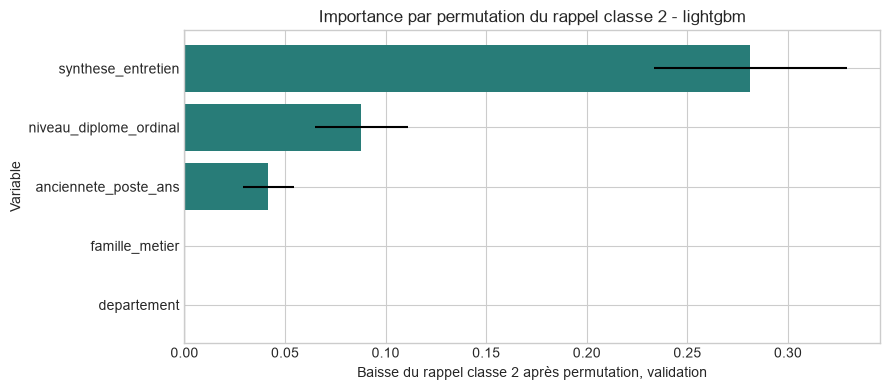

In [220]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

best_model_name = baseline_df.sort_values(
    ["cout_metier_validation", "recall_classe_2", "f1_macro"],
    ascending=[True, False, False],
).iloc[0]["model"]
best_pipeline = best_models[best_model_name].best_estimator_
recall_classe_2_scorer = make_scorer(
    recall_score,
    labels=[2],
    average="macro",
    zero_division=0,
)

print(f"Meilleur modèle de base sur validation : {best_model_name}")
print(
    "Erreurs critiques 2 -> 0 sur validation : "
    f"{baseline_df.loc[baseline_df['model'] == best_model_name, 'erreurs_2_vers_0'].iloc[0]}"
)

permutation_result = permutation_importance(
    estimator=best_pipeline,
    X=X_validation_s,
    y=y_validation_s,
    scoring=recall_classe_2_scorer,
    n_repeats=5,
    random_state=SEED,
    n_jobs=1,
)

importance_df = pd.DataFrame({
    "variable": X_validation_s.columns,
    "importance_moyenne": permutation_result.importances_mean,
    "ecart_type": permutation_result.importances_std,
}).sort_values("importance_moyenne", ascending=False)

display(importance_df.round(4))

plot_data = importance_df.sort_values("importance_moyenne", ascending=True)
figure, axes = plt.subplots(figsize=(9, max(4, 0.45 * len(plot_data))))
axes.barh(
    plot_data["variable"],
    plot_data["importance_moyenne"],
    xerr=plot_data["ecart_type"],
    color="#287C78",
)
axes.axvline(0, color="#555555", linewidth=0.8)
axes.set_title(f"Importance par permutation du rappel classe 2 - {best_model_name}")
axes.set_xlabel("Baisse du rappel classe 2 après permutation, validation")
axes.set_ylabel("Variable")
figure.tight_layout()
plt.show()

## 12. Sélection sur validation et évaluation finale

Les hyperparamètres sont recherchés sur le train. Le modèle et le poids de classe 2 sont choisis sur la validation avec un coût métier explicite: pénalité 5 pour `2 → 0`, 2 pour `2 → 1`, et 1 pour une fausse alerte `0/1 → 2`. Le pipeline retenu est ensuite réentraîné sur train + validation; le test n'est évalué qu'une seule fois, après la sélection.

In [224]:
from sklearn.base import clone

facteurs_poids_classe_2 = [1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0]
candidats_pondere = {}
resultats_ponderation = []

for modele in ["logistic_regression", "random_forest", "lightgbm"]:
    for facteur in facteurs_poids_classe_2:
        poids_classes = {0: 1.0, 1: 1.0, 2: facteur}
        candidat = clone(best_models[modele].best_estimator_)
        candidat.set_params(model__class_weight=poids_classes)
        candidat.fit(X_train_s, y_train_s)
        prediction_validation = candidat.predict(X_validation_s)
        matrice = confusion_matrix(
            y_validation_s,
            prediction_validation,
            labels=[0, 1, 2],
        )
        erreurs_2_vers_0 = int(matrice[2, 0])
        erreurs_2_vers_1 = int(matrice[2, 1])
        erreurs_0_vers_2 = int(matrice[0, 2])
        erreurs_1_vers_2 = int(matrice[1, 2])
        cout_metier = (
            5 * erreurs_2_vers_0
            + 2 * erreurs_2_vers_1
            + erreurs_0_vers_2
            + erreurs_1_vers_2
        )
        resultats_ponderation.append({
            "modele": modele,
            "poids_classe_2": facteur,
            "erreurs_2_vers_0": erreurs_2_vers_0,
            "erreurs_2_vers_1": erreurs_2_vers_1,
            "fausses_alertes_0_ou_1_vers_2": erreurs_0_vers_2 + erreurs_1_vers_2,
            "cout_metier_validation": cout_metier,
            "recall_classe_2": recall_score(
                y_validation_s,
                prediction_validation,
                labels=[2],
                average=None,
                zero_division=0,
            )[0],
            "f1_macro": f1_score(
                y_validation_s,
                prediction_validation,
                average="macro",
                zero_division=0,
            ),
        })
        candidats_pondere[(modele, facteur)] = candidat

selection_df = pd.DataFrame(resultats_ponderation).sort_values(
    [
        "cout_metier_validation",
        "erreurs_2_vers_0",
        "recall_classe_2",
        "f1_macro",
    ],
    ascending=[True, True, False, False],
).reset_index(drop=True)

meilleur_candidat = selection_df.iloc[0]
best_model_name = str(meilleur_candidat["modele"])
class2_weight_factor = float(meilleur_candidat["poids_classe_2"])
best_pipeline = candidats_pondere[(best_model_name, class2_weight_factor)]
best_search = best_models[best_model_name]

print(
    f"Choix validation: {best_model_name}, poids classe 2 = "
    f"{class2_weight_factor:.1f}, coût = "
    f"{int(meilleur_candidat['cout_metier_validation'])}"
)
display(selection_df.round(4))

Choix validation: lightgbm, poids classe 2 = 2.0, coût = 160


,modele,poids_classe_2,erreurs_2_vers_0,erreurs_2_vers_1,fausses_alertes_0_ou_1_vers_2,cout_metier_validation,recall_classe_2,f1_macro
0,lightgbm,2.0,11,10,85,160,0.7692,0.6427
1,random_forest,5.0,5,6,125,162,0.8791,0.6070
2,random_forest,4.0,7,6,116,163,0.8571,0.6192
3,lightgbm,3.0,10,6,104,166,0.8242,0.6293
4,logistic_regression,5.0,8,6,117,169,0.8462,0.6133
5,random_forest,3.0,10,10,99,169,0.7802,0.6240
6,logistic_regression,3.0,11,9,97,170,0.7802,0.6311
7,lightgbm,1.5,14,14,73,171,0.6923,0.6372
8,logistic_regression,4.0,10,8,106,172,0.8022,0.6192
9,logistic_regression,2.0,11,11,96,173,0.7582,0.6281


In [225]:
X_train_s, X_validation_s, X_test_s, y_train_s, y_validation_s, y_test_s = (
    build_scenario_split(scenario_definitions[scenario_retenu_name]["features"])
)

best_class_weights = {
    0: 1.0,
    1: 1.0,
    2: class2_weight_factor,
}
best_params = dict(best_search.best_params_)
best_params["model__class_weight"] = best_class_weights

X_train_final = pd.concat([X_train_s, X_validation_s]).sort_index()
y_train_final = pd.concat([y_train_s, y_validation_s]).sort_index()

best_pipeline = clone(best_search.best_estimator_)
best_pipeline.set_params(**best_params)
best_pipeline.fit(X_train_final, y_train_final)

# Unique consultation du test, après le choix du scénario, du modèle et des poids.
y_test_pred = best_pipeline.predict(X_test_s)
best_metrics = compute_metrics(y_test_s, y_test_pred)
best_validation_metrics = meilleur_candidat.to_dict()

print(f"Modèle sélectionné sur validation : {best_model_name}")
print(f"Poids de classe 2 : {class2_weight_factor:.1f}")
print(f"Coût métier validation : {int(meilleur_candidat['cout_metier_validation'])}")
print(f"Lignes utilisées pour le refit final : {len(X_train_final)}")
print("Évaluation finale sur le test réservé :")
print(f"Accuracy : {best_metrics['accuracy']:.4f}")
print(f"F1 macro : {best_metrics['f1_macro']:.4f}")
print(f"Recall classe 2 : {best_metrics['recall_classe_2']:.4f}")
print(f"Erreurs critiques 2 -> 0 : {best_metrics['erreurs_2_vers_0']}")
display(
    pd.DataFrame(
        best_metrics["confusion_matrix"],
        index=["Réel 0", "Réel 1", "Réel 2"],
        columns=["Prédit 0", "Prédit 1", "Prédit 2"],
    )
)

Modèle sélectionné sur validation : lightgbm
Poids de classe 2 : 2.0
Coût métier validation : 160
Lignes utilisées pour le refit final : 2000
Évaluation finale sur le test réservé :
Accuracy : 0.6440
F1 macro : 0.6251
Recall classe 2 : 0.6333
Erreurs critiques 2 -> 0 : 14


,Prédit 0,Prédit 1,Prédit 2
Réel 0,117,37,33
Réel 1,37,148,38
Réel 2,14,19,57


<h4 style="color:green">Jdb : jour 15 : ML Flow

In [ ]:
import joblib

scenario_name = scenario_retenu_name
artifact_path = C.DIR_MODELS / "pipeline_meilleur_recall_f1.joblib"
C.DIR_MODELS.mkdir(parents=True, exist_ok=True)

validation_metrics = {
    "class2_weight_factor": class2_weight_factor,
    "erreurs_2_vers_0": int(best_validation_metrics["erreurs_2_vers_0"]),
    "erreurs_2_vers_1": int(best_validation_metrics["erreurs_2_vers_1"]),
    "fausses_alertes_0_ou_1_vers_2": int(
        best_validation_metrics["fausses_alertes_0_ou_1_vers_2"]
    ),
    "cout_metier": int(best_validation_metrics["cout_metier_validation"]),
    "recall_classe_2": float(best_validation_metrics["recall_classe_2"]),
    "f1_macro": float(best_validation_metrics["f1_macro"]),
}

retraining_config = {
    "scenario_name": scenario_name,
    "model_name": best_model_name,
    "target": C.CIBLE,
    "features": list(scenario_definitions[scenario_name]["features"]),
    "data_file": str(C.DEMANDEUR_FILE),
    "data_preparation": "src.train_model.prepare_dataframe",
    "random_state": int(SEED),
    "test_size": 0.2,
    "cross_validation": {
        "class": "StratifiedKFold",
        "n_splits": int(cv.n_splits),
        "shuffle": bool(cv.shuffle),
        "random_state": int(SEED),
        "scoring": "f1_macro",
        "search": "RandomizedSearchCV",
        "n_iter": 10,
    },
    "selection_metric": "validation_cost_5x_2_to_0_2x_2_to_1_1x_false_positive_2",
    "class2_weight_factor": class2_weight_factor,
    "validation_metrics": validation_metrics,
    "best_params": best_params,
    "estimator_params": best_pipeline.named_steps["model"].get_params(deep=False),
    "metrics_test": {
        "accuracy": float(best_metrics["accuracy"]),
        "balanced_accuracy": float(best_metrics["balanced_accuracy"]),
        "f1_macro": float(best_metrics["f1_macro"]),
        "recall_classe_2": float(best_metrics["recall_classe_2"]),
        "erreurs_2_vers_0": int(best_metrics["erreurs_2_vers_0"]),
        "erreurs_2_vers_1": int(best_metrics["erreurs_2_vers_1"]),
    },
}

mlflow_params = {
    "scenario": scenario_name,
    "model": best_model_name,
    "target": C.CIBLE,
    "selection_metric": retraining_config["selection_metric"],
    "class2_weight_factor": class2_weight_factor,
    "random_state": int(SEED),
    "test_size": 0.2,
    "validation_size": 0.2,
    "cv_type": "StratifiedKFold",
    "cv_n_splits": int(cv.n_splits),
    "cv_scoring": "f1_macro",
    "search_type": "RandomizedSearchCV",
    "search_n_iter": 10,
}
mlflow_params.update({
    f"best_param_{name}": str(value)
    for name, value in best_params.items()
})

with mlflow.start_run(run_name=f"{scenario_name}_{best_model_name}_cost_selected") as mlflow_run:
    retraining_config["mlflow_run_id"] = mlflow_run.info.run_id
    joblib.dump(
        {
            "artifact_version": 1,
            "pipeline": best_pipeline,
            "retraining_config": retraining_config,
        },
        artifact_path,
    )

    mlflow.set_tags({
        "selection_metric": retraining_config["selection_metric"],
        "artifact_path": str(artifact_path),
        "test_used_for_selection": "false",
    })
    mlflow.log_params(mlflow_params)
    mlflow.log_metrics({
        "cout_metier_validation": validation_metrics["cout_metier"],
        "erreurs_2_vers_0_validation": validation_metrics["erreurs_2_vers_0"],
        "recall_classe_2_validation": validation_metrics["recall_classe_2"],
        "accuracy_test": retraining_config["metrics_test"]["accuracy"],
        "balanced_accuracy_test": retraining_config["metrics_test"]["balanced_accuracy"],
        "f1_macro_test": retraining_config["metrics_test"]["f1_macro"],
        "recall_classe_2_test": retraining_config["metrics_test"]["recall_classe_2"],
        "erreurs_2_vers_0_test": retraining_config["metrics_test"]["erreurs_2_vers_0"],
    })
    mlflow.log_dict(
        {
            "labels": [0, 1, 2],
            "matrix": np.asarray(best_metrics["confusion_matrix"]).tolist(),
        },
        "evaluation/confusion_matrix_test.json",
    )
    mlflow.log_artifact(str(artifact_path), artifact_path="pipeline")

print(f"Modèle sélectionné sur validation : {best_model_name}")
print(f"Poids classe 2 : {class2_weight_factor:.1f}")
print(f"Coût validation : {validation_metrics['cout_metier']}")
print(f"Erreurs 2 -> 0 sur test réservé : {best_metrics['erreurs_2_vers_0']}")
print(f"F1 macro test : {best_metrics['f1_macro']:.4f}")
print(f"Pipeline sauvegardé : {artifact_path}")
print(f"Run MLflow : {mlflow_run.info.run_id}")


def reconstruire_pipeline(config, X_train, y_train):
    """Reconstruit puis réentraîne le pipeline avec la configuration sauvegardée."""
    pipeline = build_pipeline(config["scenario_name"], config["model_name"])
    pipeline.set_params(**config["best_params"])
    return pipeline.fit(X_train, y_train)

<h4 style="color:green">Jdb : jour 14 : developement de l'API et Test via Swagger

## 13. Test de l'API
L'API est testé unitairement via swagger : http://127.0.0.1:8000/docs


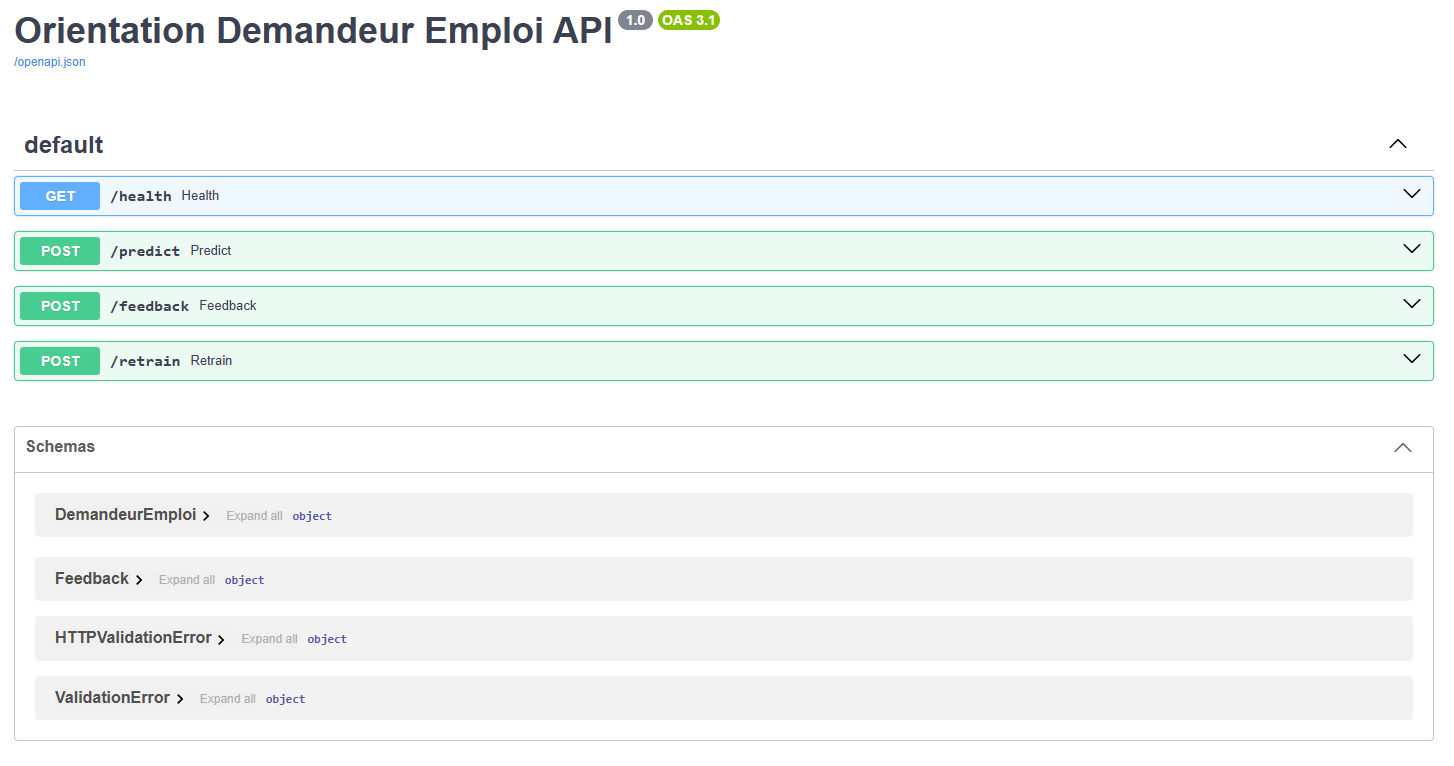

<h4 style="color:green">Jdb : jour 16 : Mise en place de docker

## 14. Docker
Construction d'une image Docker de l'API et déployement sur l'infrastructure cible

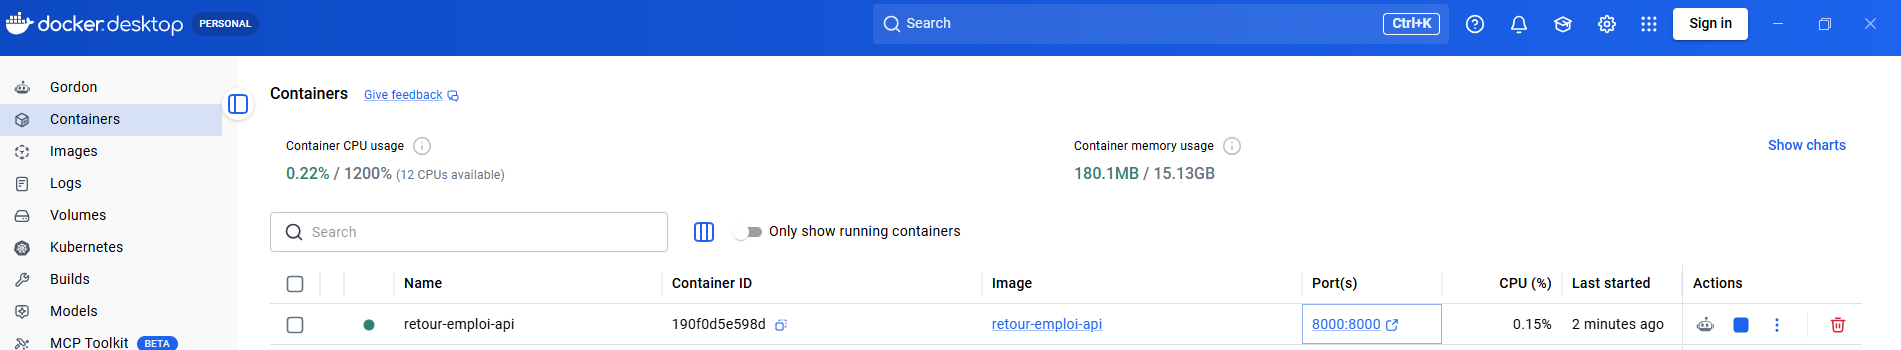

<h4 style="color:green">Jdb : jour 17 : CI/CD Github action et tests

## 15. Gisthub Action
Utilisation de github action pour automatiser GitHub Actions pour automatiser les étapes clés du cycle de vie du code C

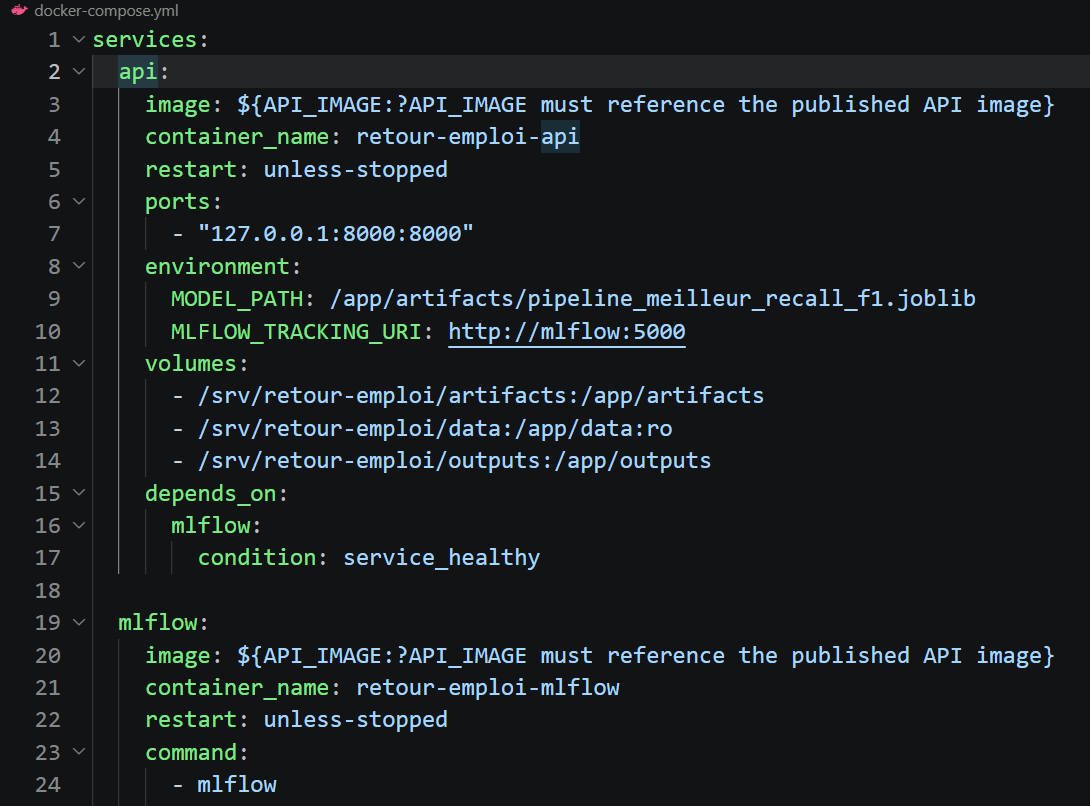

<h4 style="color:green">Jdb : jour 17 : CI/CD Github action

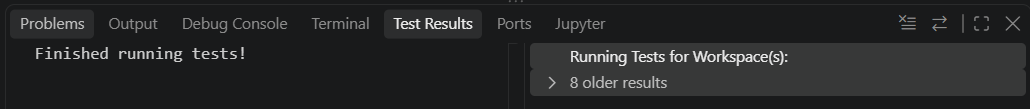